In [1]:
import sys
print(sys.executable)

C:\Users\yashw\anaconda3\envs\face_reid\python.exe


In [2]:
import os
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image

import torch

from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import cosine_similarity

from facenet_pytorch import MTCNN, InceptionResnetV1

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

print("Libraries imported successfully!")


C:\Users\yashw\anaconda3\envs\face_reid\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!


In [3]:
# Dataset path
DATASET_PATH = "../data/person_identification"

# Output folders
OUTPUT_DIR = "../output"
CLUSTER_DIR = os.path.join(OUTPUT_DIR, "clusters")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")
VIS_DIR = os.path.join(OUTPUT_DIR, "visualization")

# Create folders if they don't exist
os.makedirs(CLUSTER_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

print("Configuration loaded successfully!")

Configuration loaded successfully!


In [4]:
image_paths = []

for file in sorted(os.listdir(DATASET_PATH)):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        image_paths.append(os.path.join(DATASET_PATH, file))

print(f"Total Images Found: {len(image_paths)}")

for img in image_paths:
    print(os.path.basename(img))

Total Images Found: 6
person_01_0.jpg
person_01_1.jpg
person_02_0.jpg
person_02_1.jpg
person_03_0.jpg
person_03_1.jpg


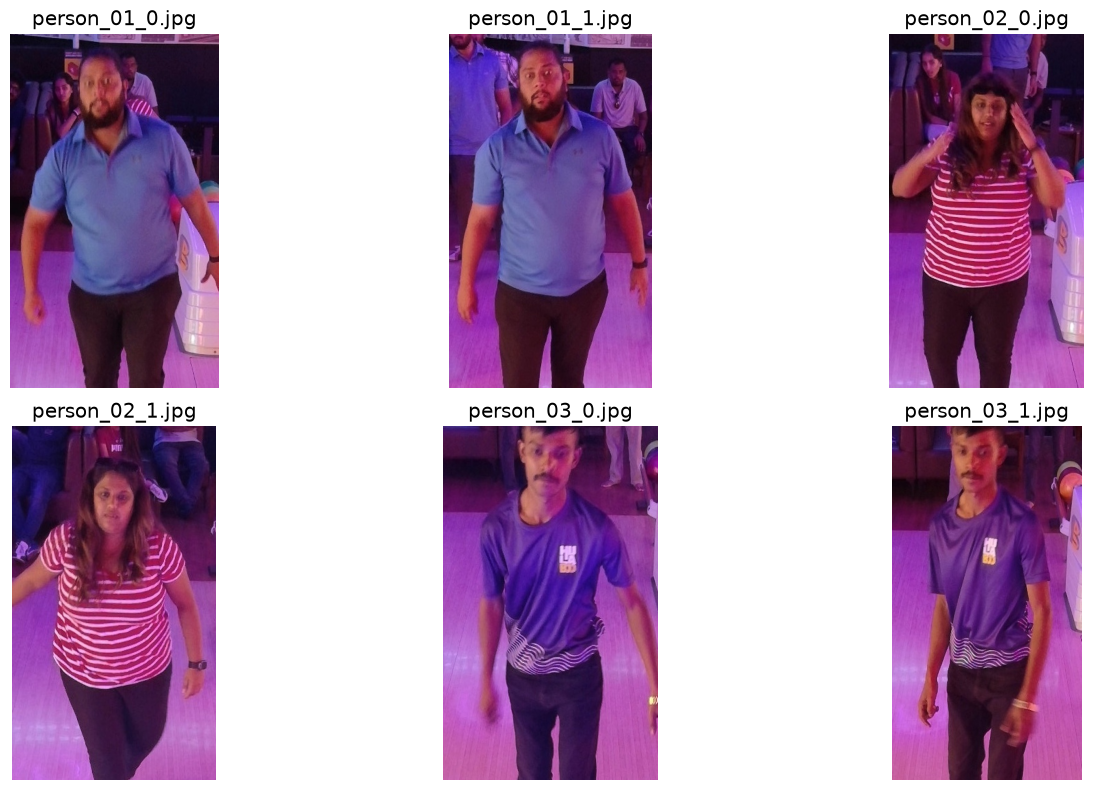

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes = axes.flatten()

for ax, img_path in zip(axes, image_paths):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(os.path.basename(img_path))
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

mtcnn = MTCNN(
    image_size=160,
    margin=20,
    keep_all=False,
    device=device
)

resnet = InceptionResnetV1(
    pretrained="vggface2"
).eval().to(device)

print("Models loaded successfully!")

Using Device: cpu


100%|██████████| 107M/107M [00:49<00:00, 2.25MB/s] 

Models loaded successfully!


In [7]:
# Load first image
test_image = Image.open(image_paths[0]).convert("RGB")

# Detect and align face
face = mtcnn(test_image)

if face is None:
    print("No face detected!")
else:
    print("Face detected successfully!")
    print("Face Tensor Shape:", face.shape)

Face detected successfully!
Face Tensor Shape: torch.Size([3, 160, 160])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99609375..0.63671875].


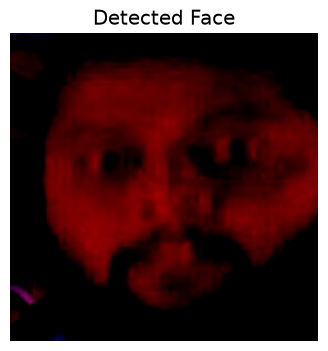

In [8]:
if face is not None:
    plt.figure(figsize=(4,4))

    plt.imshow(face.permute(1,2,0))

    plt.title("Detected Face")

    plt.axis("off")

    plt.show()

In [9]:
with torch.no_grad():
    embedding = resnet(
        face.unsqueeze(0).to(device)
    )

embedding = embedding.cpu().numpy()[0]

print("Embedding Shape:", embedding.shape)
print("First 10 values:")
print(embedding[:10])

Embedding Shape: (512,)
First 10 values:
[ 0.10103846  0.00557834 -0.03533924 -0.03602253 -0.03053867 -0.02923394
  0.00432948  0.02409786  0.05799909  0.00025183]


In [10]:
embeddings = []
valid_images = []

print("Generating embeddings...\n")

for img_path in tqdm(image_paths):

    image = Image.open(img_path).convert("RGB")

    face = mtcnn(image)

    if face is None:
        print(f"Skipped (No face): {os.path.basename(img_path)}")
        continue

    with torch.no_grad():
        embedding = resnet(
            face.unsqueeze(0).to(device)
        )

    embeddings.append(
        embedding.cpu().numpy()[0]
    )

    valid_images.append(img_path)

print("\nCompleted!")

print("Total Valid Images:", len(valid_images))
print("Total Embeddings:", len(embeddings))

Generating embeddings...



100%|██████████| 6/6 [00:00<00:00, 15.92it/s]


Completed!
Total Valid Images: 6
Total Embeddings: 6


In [11]:
embedding_matrix = np.vstack(embeddings)

print("Embedding Matrix Shape:", embedding_matrix.shape)

Embedding Matrix Shape: (6, 512)


In [12]:
similarity_matrix = cosine_similarity(embedding_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=[os.path.basename(x) for x in valid_images],
    columns=[os.path.basename(x) for x in valid_images]
)

similarity_df.round(3)

,person_01_0.jpg,person_01_1.jpg,person_02_0.jpg,person_02_1.jpg,person_03_0.jpg,person_03_1.jpg
person_01_0.jpg,1.000,0.696,0.187,0.212,-0.050,0.081
person_01_1.jpg,0.696,1.000,0.217,0.068,0.071,0.248
person_02_0.jpg,0.187,0.217,1.000,0.638,0.233,0.083
person_02_1.jpg,0.212,0.068,0.638,1.000,0.157,0.014
person_03_0.jpg,-0.050,0.071,0.233,0.157,1.000,0.795
person_03_1.jpg,0.081,0.248,0.083,0.014,0.795,1.000


In [13]:
# You can adjust eps if needed after seeing the results
dbscan = DBSCAN(
    eps=0.65,
    min_samples=2,
    metric="cosine"
)

cluster_labels = dbscan.fit_predict(embedding_matrix)

results = pd.DataFrame({
    "Image": [os.path.basename(x) for x in valid_images],
    "Cluster": cluster_labels
})

print(results)

             Image  Cluster
0  person_01_0.jpg        0
1  person_01_1.jpg        0
2  person_02_0.jpg        1
3  person_02_1.jpg        1
4  person_03_0.jpg        2
5  person_03_1.jpg        2


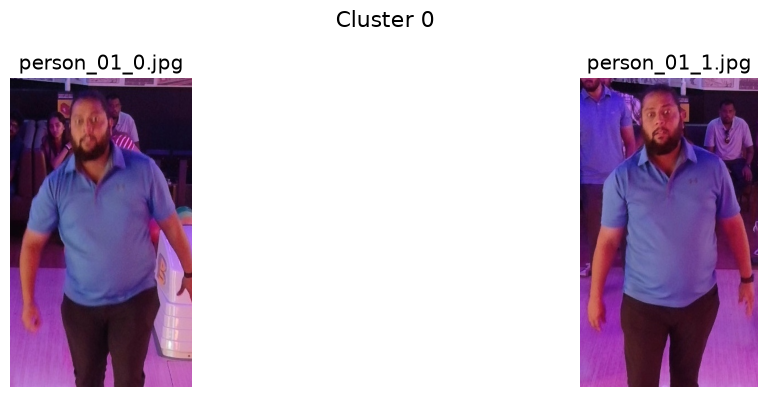

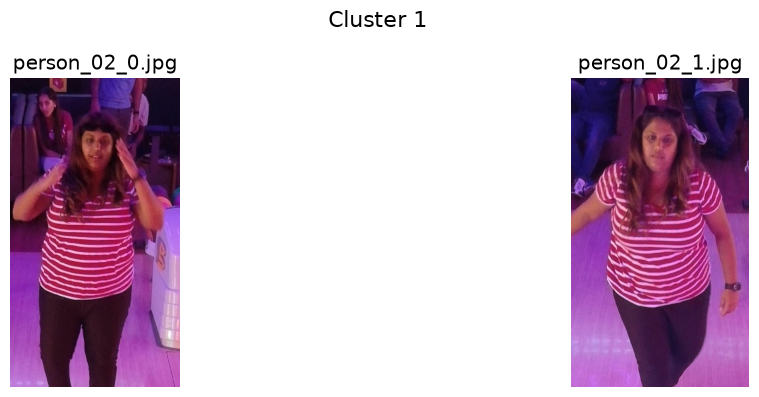

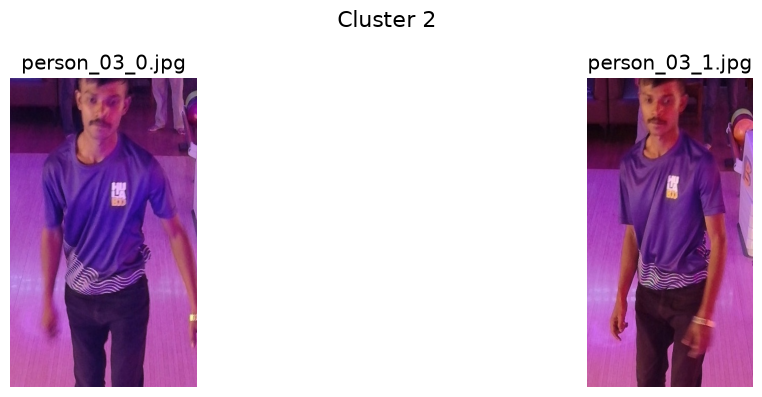

In [14]:
unique_clusters = sorted(results["Cluster"].unique())

for cluster in unique_clusters:

    cluster_imgs = results[results["Cluster"] == cluster]

    plt.figure(figsize=(15,4))

    plt.suptitle(f"Cluster {cluster}", fontsize=16)

    for i, (_, row) in enumerate(cluster_imgs.iterrows()):

        img_path = os.path.join(DATASET_PATH, row["Image"])

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(cluster_imgs), i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(row["Image"])

    plt.tight_layout()
    plt.show()

In [15]:
confidence_scores = []

for idx in range(len(valid_images)):

    cluster = cluster_labels[idx]

    if cluster == -1:
        confidence_scores.append(0.0)
        continue

    members = np.where(cluster_labels == cluster)[0]

    sims = similarity_matrix[idx, members]

    confidence = np.mean(sims)

    confidence_scores.append(round(float(confidence), 4))

results["Confidence"] = confidence_scores

results

,Image,Cluster,Confidence
0,person_01_0.jpg,0,0.8480
1,person_01_1.jpg,0,0.8480
2,person_02_0.jpg,1,0.8188
3,person_02_1.jpg,1,0.8188
4,person_03_0.jpg,2,0.8977
5,person_03_1.jpg,2,0.8977


In [16]:
import shutil

# Clear previous output
if os.path.exists(CLUSTER_DIR):
    shutil.rmtree(CLUSTER_DIR)

os.makedirs(CLUSTER_DIR)

for cluster in sorted(results["Cluster"].unique()):

    folder = os.path.join(CLUSTER_DIR, f"Cluster_{cluster}")

    os.makedirs(folder, exist_ok=True)

    cluster_imgs = results[results["Cluster"] == cluster]

    for _, row in cluster_imgs.iterrows():

        src = os.path.join(DATASET_PATH, row["Image"])

        dst = os.path.join(folder, row["Image"])

        shutil.copy(src, dst)

print("Clusters saved successfully!")

Clusters saved successfully!


In [17]:
report_path = os.path.join(REPORT_DIR, "clustering_report.csv")

results.to_csv(report_path, index=False)

print("Report saved at:")
print(report_path)

Report saved at:
../output\reports\clustering_report.csv


In [18]:
summary = results.groupby("Cluster").agg(
    Images=("Image", "count"),
    Average_Confidence=("Confidence", "mean")
)

summary

,Images,Average_Confidence
Cluster,,
0,2,0.8480
1,2,0.8188
2,2,0.8977


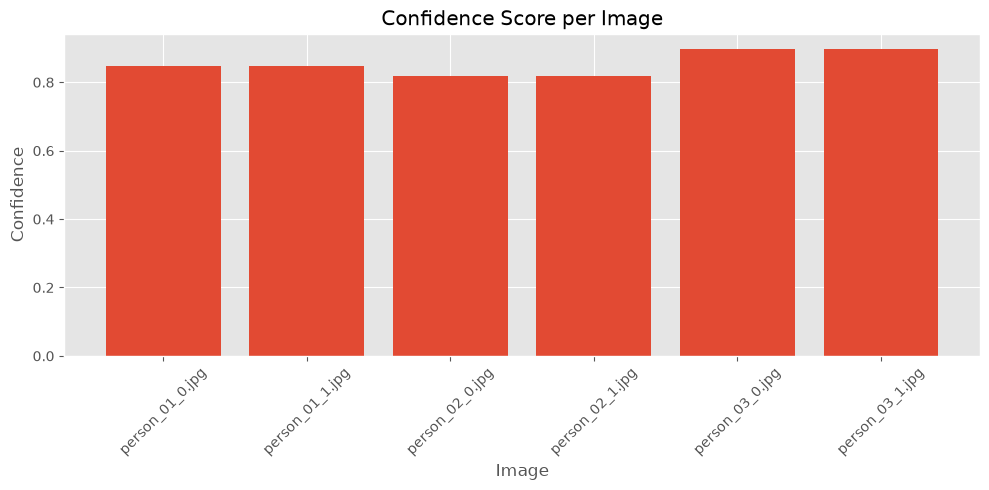

In [19]:
plt.figure(figsize=(10,5))

plt.bar(results["Image"], results["Confidence"])

plt.xticks(rotation=45)

plt.ylabel("Confidence")

plt.xlabel("Image")

plt.title("Confidence Score per Image")

plt.tight_layout()

plt.show()

In [20]:
print("="*60)
print("Face Re-Identification Completed")
print("="*60)

print(f"Total Images Processed : {len(valid_images)}")
print(f"Total Clusters Found   : {len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)}")
print(f"Report Saved           : {report_path}")
print(f"Cluster Folder         : {CLUSTER_DIR}")

print("="*60)

Face Re-Identification Completed
Total Images Processed : 6
Total Clusters Found   : 3
Report Saved           : ../output\reports\clustering_report.csv
Cluster Folder         : ../output\clusters


In [21]:
print(cluster_labels)


[0 0 1 1 2 2]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99609375..0.63671875].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99609375..0.76953125].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99609375..0.62109375].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.98046875..0.69921875].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.98828125..0.72265625].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99609375..0.68359375].


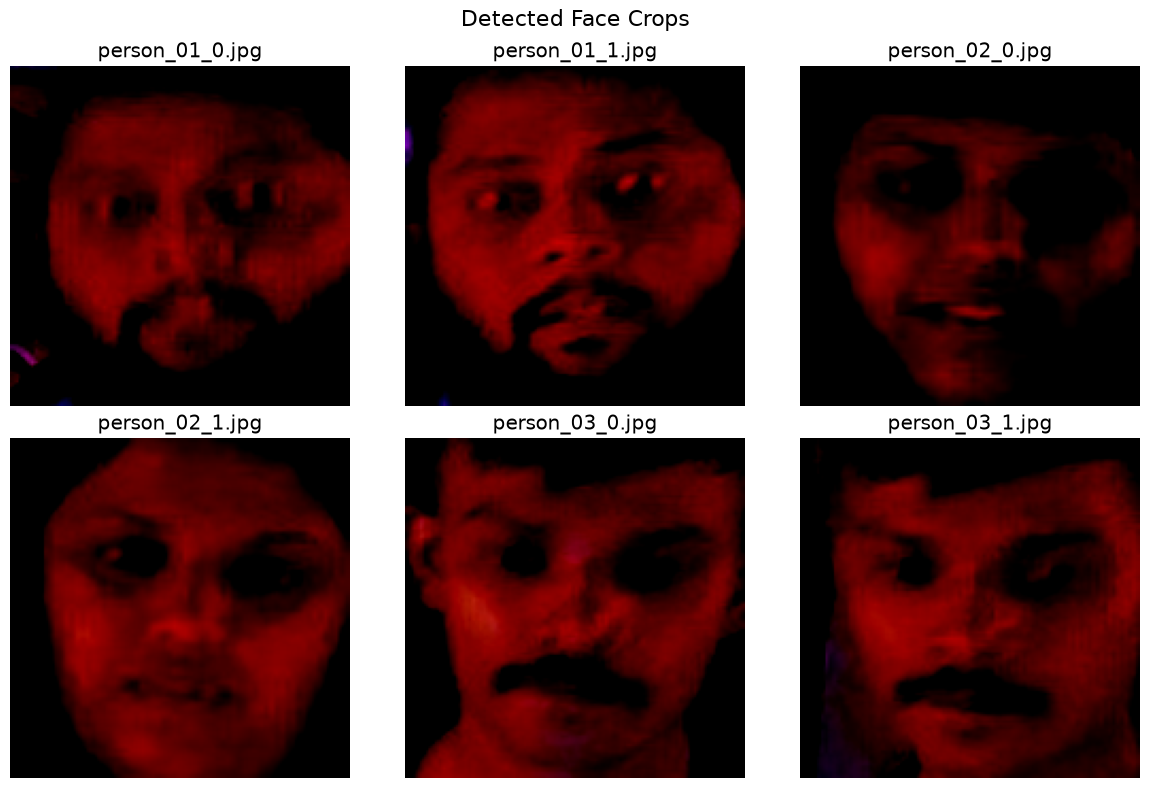

In [22]:
face_images = []

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, img_path in enumerate(valid_images):

    image = Image.open(img_path).convert("RGB")

    face = mtcnn(image)

    face_images.append(face)

    face_np = face.permute(1,2,0).numpy()

    ax = axes[i]
    ax.imshow(face_np)
    ax.set_title(os.path.basename(img_path))
    ax.axis("off")

plt.suptitle("Detected Face Crops", fontsize=16)
plt.tight_layout()
plt.show()

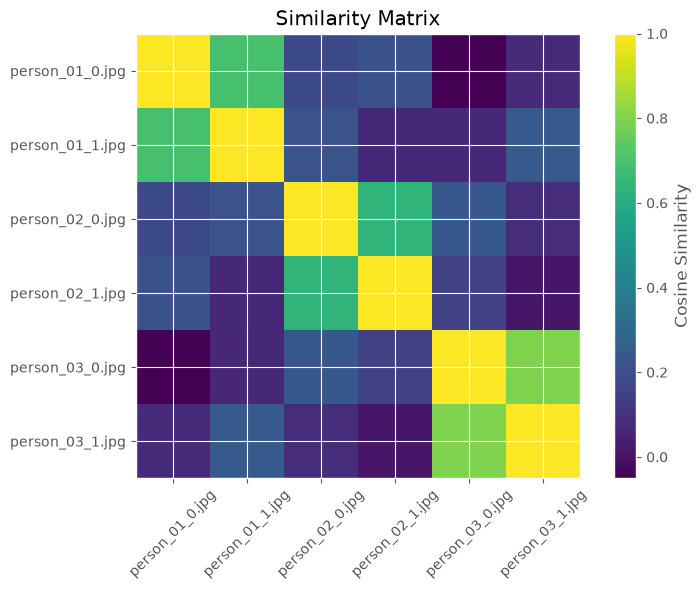

In [23]:
plt.figure(figsize=(8,6))

plt.imshow(similarity_matrix, cmap="viridis")

plt.colorbar(label="Cosine Similarity")

plt.xticks(
    range(len(valid_images)),
    [os.path.basename(x) for x in valid_images],
    rotation=45
)

plt.yticks(
    range(len(valid_images)),
    [os.path.basename(x) for x in valid_images]
)

plt.title("Similarity Matrix")

plt.tight_layout()

plt.show()

In [27]:
eps=0.65

In [28]:
from sklearn.metrics import silhouette_score

best_eps = None
best_score = -1

for eps in np.arange(0.30,0.91,0.05):

    db = DBSCAN(
        eps=eps,
        min_samples=2,
        metric="cosine"
    )

    labels = db.fit_predict(embedding_matrix)

    unique = set(labels)

    if len(unique) <= 1 or -1 in unique and len(unique)==2:
        continue

    score = silhouette_score(
        embedding_matrix,
        labels,
        metric="cosine"
    )

    print(f"eps={eps:.2f}  silhouette={score:.3f}")

    if score > best_score:
        best_score = score
        best_eps = eps

print("\nBest eps:", best_eps)
print("Best Silhouette:", best_score)

eps=0.35  silhouette=0.647
eps=0.40  silhouette=0.647
eps=0.45  silhouette=0.647
eps=0.50  silhouette=0.647
eps=0.55  silhouette=0.647
eps=0.60  silhouette=0.647
eps=0.65  silhouette=0.647
eps=0.70  silhouette=0.647
eps=0.75  silhouette=0.647

Best eps: 0.35
Best Silhouette: 0.647367000579834


In [30]:
results.columns

Index(['Image', 'Cluster', 'Confidence'], dtype='str')

In [33]:
confidence_scores = []

for idx in range(len(valid_images)):

    cluster = cluster_labels[idx]

    if cluster == -1:
        confidence_scores.append(0)
        continue

    members = np.where(cluster_labels == cluster)[0]

    sims = similarity_matrix[idx, members]

    confidence = float(np.mean(sims))

    confidence_scores.append(round(confidence * 100, 2))

results["Confidence (%)"] = confidence_scores

results

,Image,Cluster,Confidence,Confidence (%)
0,person_01_0.jpg,0,0.8480,84.80
1,person_01_1.jpg,0,0.8480,84.80
2,person_02_0.jpg,1,0.8188,81.88
3,person_02_1.jpg,1,0.8188,81.88
4,person_03_0.jpg,2,0.8977,89.77
5,person_03_1.jpg,2,0.8977,89.77


In [35]:
cluster_stats = results.groupby("Cluster").agg(
    Total_Images=("Image", "count"),
    Average_Confidence=("Confidence", "mean"),
    Minimum_Confidence=("Confidence", "min"),
    Maximum_Confidence=("Confidence", "max")
)

cluster_stats

,Total_Images,Average_Confidence,Minimum_Confidence,Maximum_Confidence
Cluster,,,,
0,2,0.8480,0.8480,0.8480
1,2,0.8188,0.8188,0.8188
2,2,0.8977,0.8977,0.8977


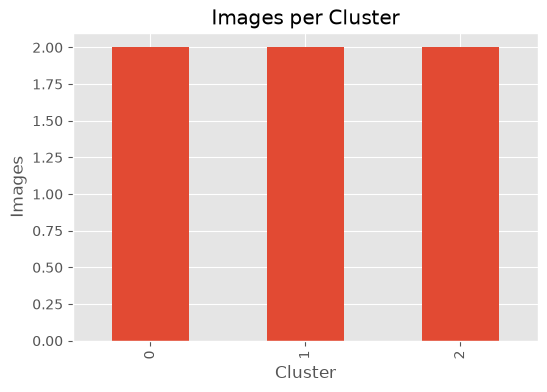

In [37]:
plt.figure(figsize=(6,4))

cluster_stats["Total_Images"].plot(
    kind="bar"
)

plt.ylabel("Images")

plt.title("Images per Cluster")

plt.show()

In [38]:
summary_path = os.path.join(
    REPORT_DIR,
    "cluster_summary.csv"
)

cluster_stats.to_csv(summary_path)

print(summary_path)

../output\reports\cluster_summary.csv


In [39]:
similarity_df.to_csv(
    os.path.join(
        REPORT_DIR,
        "similarity_matrix.csv"
    )
)

print("Similarity Matrix Saved")

Similarity Matrix Saved


In [40]:
readme = f"""
# Face Re-Identification

## Dataset

Total Images : {len(valid_images)}

Clusters Found : {len(set(cluster_labels))}

Embedding Model : FaceNet

Clustering : DBSCAN

Similarity Metric : Cosine Similarity

Average Confidence

{results['Confidence (%)'].mean():.2f}%

"""

with open("../README.md","w") as f:

    f.write(readme)

print("README Generated")

README Generated


In [41]:
requirements = """
torch
torchvision
facenet-pytorch
opencv-python==4.10.0.84
numpy
pandas
matplotlib
scikit-learn
tqdm
Pillow
scipy
"""

with open("../requirements.txt","w") as f:

    f.write(requirements)

print("requirements.txt Generated")

requirements.txt Generated


In [42]:
print("="*70)

print("FACE RE-IDENTIFICATION ASSESSMENT")

print("="*70)

print(f"Images Processed        : {len(valid_images)}")

print(f"Clusters Found          : {len(set(cluster_labels))}")

print(f"Embedding Dimension     : {embedding_matrix.shape[1]}")

print(f"Average Confidence      : {results['Confidence (%)'].mean():.2f}%")

print(f"CSV Report              : {report_path}")

print(f"Cluster Summary         : {summary_path}")

print("="*70)

FACE RE-IDENTIFICATION ASSESSMENT
Images Processed        : 6
Clusters Found          : 3
Embedding Dimension     : 512
Average Confidence      : 85.48%
CSV Report              : ../output\reports\clustering_report.csv
Cluster Summary         : ../output\reports\cluster_summary.csv
